In [57]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import InMemorySaver


In [58]:

model = ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio",
    temperature=0
)

In [59]:
# model.invoke("how are you?").content

In [60]:
class JokeState(TypedDict):
    topic : str
    joke : str
    explanation : str

In [61]:
def generate_joke(state : JokeState):
    prompt = f" generate a joke on the topic {state["topic"]}"
    response = model.invoke(prompt).content

    return {'joke' : response}
    

In [62]:
def joke_explanation(state: JokeState):
    prompt = f"explain the give joke {state["joke"]}"
    response = model.invoke(prompt).content

    return {'explanation' : response}

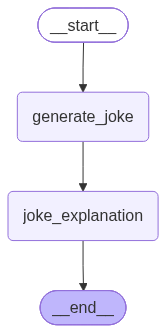

In [63]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("joke_explanation", joke_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'joke_explanation')
graph.add_edge('joke_explanation', END)

checkpointer = InMemorySaver()
graph.compile()

In [72]:
workflow = graph.compile(checkpointer=checkpointer)

initial_state = {
    "topic" : "aloo"
}

config1 = {"configurable" : {"thread_id" : "1"}}
workflow.invoke(initial_state, config= config1)

{'topic': 'aloo',
 'joke': 'Sure! Here\'s a playful aloo (potato) joke for you:\n\nWhy did the potato go to therapy?\n\nBecause it had deep roots and a lot of emotional baggage — and it just couldn’t *potato* itself out of the situation! 🥔😄\n\n(And yes, it’s a pun on "potato" and "potato" as in "to pot" — hope you enjoyed the root of the humor!)',
 'explanation': 'Absolutely! Let\'s break down that deliciously rooted joke — because, well, it\'s *potato*-nally funny!\n\n**Joke:**  \n*Why did the potato go to therapy?*  \n*Because it had deep roots and a lot of emotional baggage — and it just couldn’t *potato* itself out of the situation!* 🥔😄\n\n---\n\n### 🎯 The Humor Breakdown:\n\n1. **"Deep roots"**  \n   → This is a literal pun. Potatoes grow from roots, so "deep roots" is a perfect metaphor for someone with strong, grounded (and possibly problematic) emotional foundations. It\'s a clever play on the idea of "having roots" in life — like being deeply connected to one\'s past.\n\n2. **

In [75]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'tomato', 'joke': 'Why did the tomato turn red?\n\nBecause it saw the salad dressing! 🍅😄\n\n(Also, it was *not* a vegetable — it was a *fruit*!) 🍓', 'explanation': 'Ah, the classic "why did the tomato turn red?" joke — a delightful example of a pun-based humor!\n\nLet’s break it down:\n\n**The Joke:**  \n*Why did the tomato turn red?*  \n→ *Because it saw the salad dressing!* 🍅😄\n\n**The Humor:**  \nThis is a **pun** — a play on words. The joke works because:\n\n- "Turned red" sounds like "turned red" (a literal color change), but it also plays on the word *red* in the context of a tomato\'s natural color.\n- "Saw the salad dressing" is a silly, absurd reason — just like how a person might say "I saw a red car" — but here, it\'s a *vegetable* (tomato) "seeing" something, which is ridiculous in reality.\n- The humor comes from the absurdity of a tomato *seeing* anything — especially in a kitchen setting — and the unexpected twist that it\'s not just a vege

In [74]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'tomato', 'joke': 'Why did the tomato turn red?\n\nBecause it saw the salad dressing! 🍅😄\n\n(Also, it was *not* a vegetable — it was a *fruit*!) 🍓', 'explanation': 'Ah, the classic "why did the tomato turn red?" joke — a delightful example of a pun-based humor!\n\nLet’s break it down:\n\n**The Joke:**  \n*Why did the tomato turn red?*  \n→ *Because it saw the salad dressing!* 🍅😄\n\n**The Humor:**  \nThis is a **pun** — a play on words. The joke works because:\n\n- "Turned red" sounds like "turned red" (a literal color change), but it also plays on the word *red* in the context of a tomato\'s natural color.\n- "Saw the salad dressing" is a silly, absurd reason — just like how a person might say "I saw a red car" — but here, it\'s a *vegetable* (tomato) "seeing" something, which is ridiculous in reality.\n- The humor comes from the absurdity of a tomato *seeing* anything — especially in a kitchen setting — and the unexpected twist that it\'s not just a veg

# Time Travel

In [80]:
workflow.get_state({"configurable" : {"thread_id" : "2", "checkpoint_id" : "1f1bf0ce-9ddd-60c2-8000-0eaa6eea4771"}})

StateSnapshot(values={'topic': 'tomato'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1bf0ce-9ddd-60c2-8000-0eaa6eea4771'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-10-03T09:29:20.933702+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf0ce-9dda-6fab-bfff-c6dd0d6599b5'}}, tasks=(PregelTask(id='6c8cffe8-60a6-f0a9-62b7-4e5f54b9e7da', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the tomato turn red?\n\nBecause it saw the salad dressing! 🍅😄\n\n(Also, it was *not* a vegetable — it was a *fruit*!) 🍓'}),), interrupts=())

In [81]:
workflow.invoke(None, {"configurable" : {"thread_id" : "2", "checkpoint_id" : "1f1bf0ce-9ddd-60c2-8000-0eaa6eea4771"}})

{'topic': 'tomato',
 'joke': 'Why did the tomato go to the doctor?\n\nBecause it heard it had a *ketchup* of a problem! 🍅😄',
 'explanation': 'Great question! Let\'s break down this classic joke:\n\n**Joke:** *Why did the tomato go to the doctor?*  \n**Answer:** *Because it heard it had a ketchup of a problem!*\n\n😄\n\n### Explanation:\n\nThis is a **play on words** — a classic type of pun used in jokes.\n\n- The word **"ketchup"** is used in two different ways:\n  1. **Literal meaning**: Ketchup is a sauce made from tomatoes (or tomato-based). So, a tomato *is* part of ketchup.\n  2. **Pun on "ketchup" vs. "a problem"**: The joke plays on the phrase *"had a ketchup of a problem"* — which sounds like *"had a case of a problem"* (as in "a case of the flu" or "a case of the blues").\n\n👉 So, "a ketchup of a problem" sounds like **"a case of a problem"**, which is a silly, humorous twist on the common expression **"had a case of"** (e.g., "he had a case of the flu").\n\n### Why it\'s funny

In [82]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'tomato', 'joke': 'Why did the tomato go to the doctor?\n\nBecause it heard it had a *ketchup* of a problem! 🍅😄', 'explanation': 'Great question! Let\'s break down this classic joke:\n\n**Joke:** *Why did the tomato go to the doctor?*  \n**Answer:** *Because it heard it had a ketchup of a problem!*\n\n😄\n\n### Explanation:\n\nThis is a **play on words** — a classic type of pun used in jokes.\n\n- The word **"ketchup"** is used in two different ways:\n  1. **Literal meaning**: Ketchup is a sauce made from tomatoes (or tomato-based). So, a tomato *is* part of ketchup.\n  2. **Pun on "ketchup" vs. "a problem"**: The joke plays on the phrase *"had a ketchup of a problem"* — which sounds like *"had a case of a problem"* (as in "a case of the flu" or "a case of the blues").\n\n👉 So, "a ketchup of a problem" sounds like **"a case of a problem"**, which is a silly, humorous twist on the common expression **"had a case of"** (e.g., "he had a case of the flu").\n\

# Update State

In [87]:
workflow.update_state({"configurable" : {"thread_id" : "2", "checkpoint_id" : "1f1bf0ce-9ddd-60c2-8000-0eaa6eea4771", "checkpoint_ns" : ''}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bf0f4-c853-6a90-8001-573357bb1dc2'}}

In [88]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf0f4-c853-6a90-8001-573357bb1dc2'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-10-03T09:46:25.441038+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf0ce-9ddd-60c2-8000-0eaa6eea4771'}}, tasks=(PregelTask(id='1520f8fb-8f17-5d58-376c-541010090240', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'tomato', 'joke': 'Why did the tomato go to the doctor?\n\nBecause it heard it had a *ketchup* of a problem! 🍅😄', 'explanation': 'Great question! Let\'s break down this classic joke:\n\n**Joke:** *Why did the tomato go to the doctor?*  \n**Answer:** *Because it heard it had a ketchup of a problem!*\n\n😄\n\n### Explanation:\n\nThis is a **play on 

In [90]:
workflow.invoke(None, {"configurable" : {"thread_id" : "2", "checkpoint_id" : "1f1bf0f4-c853-6a90-8001-573357bb1dc2"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it had deep *crunch* issues! 🥟😄\n\n(And it definitely needed a little *filling* of its emotional needs!)',
 'explanation': 'Ah, what a deliciously clever joke! Let\'s break down why *"Why did the samosa go to therapy? Because it had deep *crunch* issues!"* is so funny — and how it plays on wordplay and cultural familiarity.\n\n---\n\n**1. Wordplay on "crunch":**  \nThe joke hinges on a pun. "Crunch" is a double meaning:\n\n- Literally: Samosas are crispy, crunchy snacks — their texture is a key part of their identity.  \n- Figuratively: "Crunch" can mean emotional or psychological struggles — like "crunching through tough times" or "having deep emotional issues."\n\nSo, "deep *crunch* issues" sounds like a play on "deep emotional issues" — but with a twist that fits perfectly with a samosa\'s physical traits.\n\n---\n\n**2. The humor of absurdity:**  \nThe joke is funny because it anthropomorphizes a food item (